## **Environment Setup**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/neural_networks_notebooks

/content/drive/MyDrive/neural_networks_notebooks


In [ ]:
pwd

'/content/drive/MyDrive/neural_networks_notebooks'

### **Imports**

In [ ]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## **Regularization**

### 1. **Introduction to Regularization**

Regularization is a method to **control overfitting** in machine learning and deep learning models.
A model overfits when it performs very well on training data but poorly on unseen data, meaning it has memorized rather than generalized.

Regularization prevents this by **adding constraints or penalties** during training, encouraging the model to learn **simpler patterns** that generalize better.

---

#### **1.1 Regularized Loss Function**

If the base loss function is $ L(y, \hat{y}) $, then the regularized form becomes:

$$
L_{\text{reg}} = L(y, \hat{y}) + \lambda R(w)
$$

where:

* $ L(y, \hat{y}) $: normal loss (e.g., Mean Squared Error or Cross-Entropy)
* $ R(w) $: penalty term based on model parameters
* $ \lambda $: regularization strength (higher values → stronger penalty)

---

### **2. Categories of Regularization**

| Category                                 | Core Idea                                                     | Typical Techniques                                           |
| ---------------------------------------- | ------------------------------------------------------------- | ------------------------------------------------------------ |
| **A. Weight Regularization**             | Add penalties to model weights                                | L1, L2, Elastic Net                                          |
| **B. Data-Based Regularization**         | Introduce randomness or diversity in input or activation data | Dropout, SpatialDropout, Data Augmentation, Noise Injection  |
| **C. Architectural Regularization**      | Design network structures that generalize better              | Early Stopping, Batch Normalization, Weight Sharing          |
| **D. Optimization-Based Regularization** | Modify optimization behavior for smoother convergence         | Gradient Clipping, Learning Rate Scheduling, Label Smoothing |

---

### **3. Weight Regularization (Norm-Based)**

These techniques work by discouraging the model from learning very large weight values.

---

#### **3.1 L1 Regularization (Lasso)**

**Idea:**
Penalize the **absolute magnitude** of each weight to encourage sparsity (many weights become exactly zero).

**Loss Function:**

$$
L_{\text{L1}} = L(y, \hat{y}) + \lambda \sum_i |w_i|
$$

**Effect:**

* Produces a **sparse model**, useful for feature selection.
* Optimization can be less smooth because $|w|$ is not differentiable at 0.

**PyTorch Example:**

```python
def l1_regularization(model, lambda_l1):
    l1_norm = sum(p.abs().sum() for p in model.parameters())
    return lambda_l1 * l1_norm
```

---

#### **3.2 L2 Regularization (Ridge)**

**Idea:**
Penalize the **square** of each weight to keep weights small and stable.

**Loss Function:**

$$
L_{\text{L2}} = L(y, \hat{y}) + \lambda \sum_i w_i^2
$$

**Effect:**

* Prevents extremely large weights.
* Does not create sparsity but provides smoother optimization.
* Equivalent to *weight decay* during gradient updates.

**PyTorch Example:**

```python
import torch.optim as optim
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-4)
```

---

#### **3.3 Elastic Net Regularization**

**Idea:**
Combine L1 and L2 penalties to get both sparsity and stability.

**Loss Function:**

$$
L_{\text{EN}} = L(y, \hat{y}) + \lambda_1 \sum_i |w_i| + \lambda_2 \sum_i w_i^2
$$

**Effect:**
Balances the advantages of L1 (sparsity) and L2 (smoothness).

**PyTorch Example:**

```python
def elastic_net_regularization(model, lambda_l1, lambda_l2):
    l1_norm = sum(p.abs().sum() for p in model.parameters())
    l2_norm = sum(p.pow(2).sum() for p in model.parameters())
    return lambda_l1 * l1_norm + lambda_l2 * l2_norm
```

---

### **4. Data-Based Regularization**

These techniques act on the **input data** or **intermediate activations** instead of directly modifying weights.
They increase diversity and robustness during training.

---

#### **4.1 Dropout**

**Idea:**
During training, randomly drop a fraction of neuron activations to prevent dependency among neurons.

**Operation:**

$$
h' = h \times r, \quad \text{where } r_i \sim \text{Bernoulli}(1 - p)
$$

Here:

* $ p $ = dropout rate (fraction of neurons dropped)
* $ h $ = input activations
* $ r $ = random binary mask

**Effect:**
Each mini-batch trains a slightly different sub-network.
At inference, all neurons are used but scaled by $ (1 - p) $.

**PyTorch Example:**

```python
import torch.nn as nn
model = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(256, 10)
)
```

---

#### **4.2 SpatialDropout**

**Idea:**
Special type of dropout used in **Convolutional Neural Networks (CNNs)**.
Instead of dropping individual pixels or activations, it drops **entire feature maps (channels)**.

**Reasoning:**
In CNNs, spatially adjacent activations in a feature map are highly correlated.
Dropping entire channels prevents over-reliance on specific filters and encourages other filters to learn compensating features.

**Operation:**
For an input tensor of shape `(batch, channels, height, width)`:

$$
h'*{c,:,:} =
\begin{cases}
0, & \text{if channel } c \text{ is dropped}\\
h*{c,:,:}, & \text{otherwise}\\
\end{cases}
$$

**PyTorch Example:**

```python
nn.Dropout2d(p=0.5)  # Applies SpatialDropout on 2D feature maps
```

**Effect:**

* Works better for CNNs than regular dropout.
* Ensures consistency across spatial dimensions.
* Reduces overfitting from filter co-adaptation.

---

#### **4.3 Data Augmentation**

**Idea:**
Expand the dataset by creating new samples from existing ones using transformations like rotation, flipping, or scaling.

**Effect:**

* Increases diversity without collecting new data.
* Improves robustness to changes in viewpoint, lighting, and orientation.

**PyTorch Example:**

```python
from torchvision import transforms

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])
```

---

#### **4.4 Noise Injection**

**Idea:**
Add random noise to input data or intermediate activations.

**Formula:**

$$
x' = x + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$

**Effect:**
Forces the model to learn stable features that are not overly sensitive to small perturbations.

**PyTorch Example:**

```python
noise = torch.randn_like(x) * 0.05
x_noisy = x + noise
```

---

### **5. Architectural Regularization**

These methods introduce constraints or special structures in the model architecture or training process to control overfitting.

---

#### **5.1 Early Stopping**

**Idea:**
Monitor the validation loss during training.
Stop training when the validation loss stops improving, even if training loss continues to decrease.

**Effect:**
Prevents the model from memorizing training data.

**Implementation Logic:**

```python
best_val = float('inf')
patience, counter = 5, 0

for epoch in range(epochs):
    train_loss = train(...)
    val_loss = validate(...)

    if val_loss < best_val:
        best_val = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            break
```

---

#### **5.2 Batch Normalization**

**Idea:**
Normalize the output of each layer so that its mean and variance are stable across batches.

**Formula:**
$$
\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y = \gamma \hat{x} + \beta
$$

**Effect:**

* Reduces internal covariate shift.
* Allows higher learning rates.
* Acts as a mild regularizer due to batch-wise noise.

**PyTorch Example:**

```python
nn.BatchNorm2d(64)
```

---

#### **5.3 Weight Sharing**

**Idea:**
Reuse the same set of weights across different parts of the network.
Used in **CNNs** (shared filters) and **RNNs** (shared temporal weights).

**Effect:**

* Reduces the number of trainable parameters.
* Improves generalization.
* Enforces structure and translation invariance.

---

#### **5.4 Stochastic Depth and DropConnect**

* **DropConnect:** randomly drops **weights** rather than activations.
* **Stochastic Depth:** randomly skips entire residual layers during training (common in ResNets).

**Effect:**
Both prevent the network from depending too heavily on specific paths or weights.

---

### **6. Optimization-Based Regularization**

These methods modify the optimization process itself to achieve more stable or generalizable convergence.

---

#### **6.1 Gradient Clipping**

**Idea:**
Restrict the maximum norm of gradients to avoid exploding updates.

**Operation:**
If the gradient norm exceeds a threshold $ \tau $:

$$
g = g \times \frac{\tau}{|g|}
$$

**PyTorch Example:**

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

**Effect:**
Especially useful in RNNs to maintain stable training.

---

#### **6.2 Learning Rate Scheduling**

**Idea:**
Gradually reduce the learning rate as training progresses.

**Effect:**

* Helps the model settle into smoother minima.
* Acts as implicit regularization by preventing over-correction.

**PyTorch Example:**

```python
from torch.optim.lr_scheduler import StepLR
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
for epoch in range(epochs):
    train(...)
    scheduler.step()
```

---

#### **6.3 Label Smoothing**

**Idea:**
Avoid overconfidence by converting hard one-hot labels into soft labels.

**Formula:**
$$
y'_i = (1 - \epsilon) y_i + \frac{\epsilon}{K}
$$
where:

* $ K $ = number of classes
* $ \epsilon $ = smoothing factor

**Example:**
If $ \epsilon = 0.1 $ for a 4-class problem with true label `[0,1,0,0]`,
the smoothed label becomes `[0.025, 0.925, 0.025, 0.025]`.

**PyTorch Example:**

```python
import torch.nn.functional as F
loss = F.cross_entropy(logits, targets, label_smoothing=0.1)
```

---

### **7. Comparison of Regularization Techniques**

| Technique                | Category      | Main Concept              | Primary Effect                         |
| ------------------------ | ------------- | ------------------------- | -------------------------------------- |
| L1                       | Weight-based  | Penalize absolute weights | Sparse model                           |
| L2                       | Weight-based  | Penalize squared weights  | Smooth, small weights                  |
| Elastic Net              | Weight-based  | Combine L1 and L2         | Balance between sparsity and stability |
| Dropout                  | Data-based    | Randomly drop neurons     | Reduces co-adaptation                  |
| SpatialDropout           | Data-based    | Drop entire feature maps  | Improves CNN generalization            |
| Data Augmentation        | Data-based    | Transform data            | Adds diversity                         |
| Noise Injection          | Data-based    | Add Gaussian noise        | Encourages robustness                  |
| Early Stopping           | Architectural | Halt before overfitting   | Limits memorization                    |
| Batch Normalization      | Architectural | Normalize activations     | Stabilizes and regularizes training    |
| Weight Sharing           | Architectural | Reuse parameters          | Reduces model size                     |
| Gradient Clipping        | Optimization  | Limit gradient norm       | Stabilizes updates                     |
| Learning Rate Scheduling | Optimization  | Gradually lower LR        | Smoother convergence                   |
| Label Smoothing          | Optimization  | Soften targets            | Reduces overconfidence                 |

---

### **8. Practical Guidelines**

| Scenario                               | Effective Techniques                         |
| -------------------------------------- | -------------------------------------------- |
| Small dataset, many features           | L1 / Elastic Net                             |
| Deep CNN with image data               | SpatialDropout, Data Augmentation, BatchNorm |
| RNN or sequence models                 | Gradient Clipping, L2 Regularization         |
| Overconfident classifier               | Label Smoothing                              |
| Signs of overfitting after many epochs | Early Stopping, Dropout                      |

---


## **Normalization layers**

#### **Batch Normalization (and friends) - Summarized notes**

**What/Why**
* BN stabilizes the distribution of pre-activations, enabling larger learning rates and smoother optimization; it often improves generalization.

**Deep Intuition**
* BN is like "auto-re-centering and auto-rescaling" each channel so the next layer gets predictable inputs.

**Math**
$$
\hat{x}=\frac{x-\mu_B}{\sqrt{\sigma_B^2+\epsilon}},\quad y=\gamma\hat{x}+\beta
$$
(Conv-BN-ReLU is the classic order.)

**Pitfalls**

* Small batch sizes $\Rightarrow$ noisy stats; consider **GroupNorm/LayerNorm**.

**Code**

```python
nn.BatchNorm2d(64)
# Alternatives:
nn.GroupNorm(num_groups=32, num_channels=64)  # good for small batches
```

**Measure**

* Plot running means/vars; confirm they stabilize.

---

### **Batch Normalization - Extended Notes**

##### **Concept and Motivation**

**Batch Normalization (BN)** is a technique designed to stabilize and accelerate neural network training by normalizing the intermediate feature distributions (pre-activations) within each layer.
In deep networks, as weights update, the distribution of activations shifts. This phenomenon is called *internal covariate shift*. BN mitigates this by maintaining stable mean and variance for each feature channel during training.

By normalizing intermediate outputs, BN:

* Allows higher learning rates.
* Smooths the optimization landscape.
* Accelerates convergence.
* Often improves generalization.

In essence, BN ensures that each layer receives inputs with a consistent distribution, making training more stable.

---

##### **Intuitive Understanding**

At its core, BN performs **auto re-centering and auto rescaling** of activations for each feature channel.
It behaves like an automatic "standardizer" that ensures every mini-batch has roughly zero mean and unit variance before being linearly re-scaled and shifted again via trainable parameters.

This ensures that:

* The next layer receives predictable input statistics.
* The model becomes less sensitive to weight initialization.
* The gradients flow more smoothly through the network.

In convolutional neural networks (CNNs), Batch Normalization is typically applied **per channel** across the batch and spatial dimensions, while in fully connected layers it’s applied across batch samples.

---

##### **Mathematical Formulation**

For each feature channel in a mini-batch $ B = {x_1, x_2, \dots, x_m} $:

1. **Compute the mini-batch statistics:**

$$
\mu_B = \frac{1}{m} \sum_{i=1}^m x_i, \quad \sigma_B^2 = \frac{1}{m} \sum_{i=1}^m (x_i - \mu_B)^2
$$

2. **Normalize the inputs:**

$$
\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
$$

3. **Scale and shift using learned parameters:**

$$
y_i = \gamma \hat{x}_i + \beta
$$

where:

* $ \epsilon $ is a small constant to prevent division by zero.
* $ \gamma $ (scale) and $ \beta $ (shift) are learned parameters that allow the network to restore the representational power lost during normalization.

The final normalized output is $ y_i $, which is passed to the activation function.

---

##### **Typical Placement in Networks**

The conventional order in modern architectures is:

```
Convolution → BatchNorm → ReLU (or another nonlinearity)
```

This ordering stabilizes the feature distribution before activation, ensuring smoother gradient propagation.

---

##### **Practical Interpretation**

Imagine training a deep CNN where layer 5 suddenly starts receiving activations 10× larger due to a slight parameter change in layer 3.
Without normalization, this can destabilize training.
Batch Normalization recalibrates each batch so that, regardless of earlier layers’ fluctuations, the next layer always receives input with consistent scale and mean.

This consistency:

* Acts as a mild form of regularization.
* Reduces sensitivity to initialization.
* Enables the network to train faster and more reliably.

---



##### **Implementation Example in PyTorch**

In [ ]:
import torch.nn as nn

# For a CNN layer with 64 output channels
bn = nn.BatchNorm2d(64)

# Example: Classic ordering in a block
block = nn.Sequential(
    nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True)
)


#####  **Assignment - Explain the following with a practical example.**
During training, BN maintains *running estimates* of the mean and variance, which are later used during inference for stable behavior.

---


##### **Problems with / Limitations of BN**

1. **Small Batch Sizes:**

   * BN relies on accurate estimation of batch statistics.
   * When the batch size is small, these estimates become noisy and can degrade model performance.
   * This is especially problematic in tasks like object detection, video processing, or large image models where GPU memory constraints limit batch size.

2. **Dependence on Batch Statistics:**

   * BN behaves differently during training and inference.
   * During inference, it uses accumulated running mean and variance instead of batch statistics.
   * Inconsistent estimation can cause performance gaps if not handled carefully.

3. **Order of Operations:**

   * Changing the order (e.g., ReLU before BN) can alter learning dynamics and hurt convergence.

---

##### **Alternatives to Batch Normalization**

When batch sizes are small or the task is sequential (e.g., RNNs, Transformers), other normalization methods perform better.

###### **1. Layer Normalization**

Normalizes across the feature dimension **within each individual sample** rather than across the batch.

```python
nn.LayerNorm(normalized_shape=feature_dim)
```

###### **2. Group Normalization**

Divides channels into groups and normalizes within each group.
This is often used in computer vision tasks when the batch size is small but spatial structure is important.

```python
nn.GroupNorm(num_groups=32, num_channels=64)
```

###### **3. Instance Normalization**

Used mostly in style transfer and image generation tasks; normalizes each sample and channel independently.

```python
nn.InstanceNorm2d(64)
```

---

##### **Monitoring and Evaluation**

To confirm Batch Normalization is behaving properly during training:

* Track the **running mean** and **running variance** for each feature channel.
* They should stabilize as training progresses.
* Rapid fluctuations or divergence indicate instability or excessively small batch sizes.

In PyTorch, these statistics can be accessed as:

```python
print(bn.running_mean)
print(bn.running_var)
```

Plotting their evolution over epochs can help verify training stability.

---

##### **Summary**

| Method           | Normalization Scope                     | Typical Use Case                     | Batch Dependence | Notes                              |
| ---------------- | --------------------------------------- | ------------------------------------ | ---------------- | ---------------------------------- |
| **BatchNorm**    | Across batch + spatial dims per channel | CNNs with moderate/large batch sizes | Yes              | Most common; stabilizes training   |
| **LayerNorm**    | Across feature dimension per sample     | NLP, Transformers                    | No               | Consistent for sequence models     |
| **GroupNorm**    | Across groups of channels               | CNNs with small batches              | No               | Works well in small-batch regimes  |
| **InstanceNorm** | Per channel, per sample                 | Style transfer, GANs                 | No               | Removes instance-specific contrast |

Batch Normalization remains the standard in deep CNN architectures where batch statistics are reliable, while GroupNorm and LayerNorm offer better alternatives when batch sizes are constrained or temporal dependencies exist.


## **Dropout**

#### Stochastic regularization

**What/Why**
* Dropout randomly zeroes activations at train time to prevent co-adaptation and improve robustness.

**Deep Intuition**
* Force the network to **not rely** on any single path; encourage redundancy.

**Pitfalls**
* Too high (p) harms learning.
* Post-conv dropout is less common; **SpatialDropout2d** can help.

**Code**

```python
nn.Dropout(0.5)              # classifier head
# nn.Dropout2d(p=0.2)        # spatial dropout alternative
```

**Measure**

* Compare train/val curves with/without dropout; look for reduced overfit.

---

#### Dropout vs SpatialDropout (Dropout2d) Visualization

/tmp/ipython-input-2659932997.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.9,0.95])


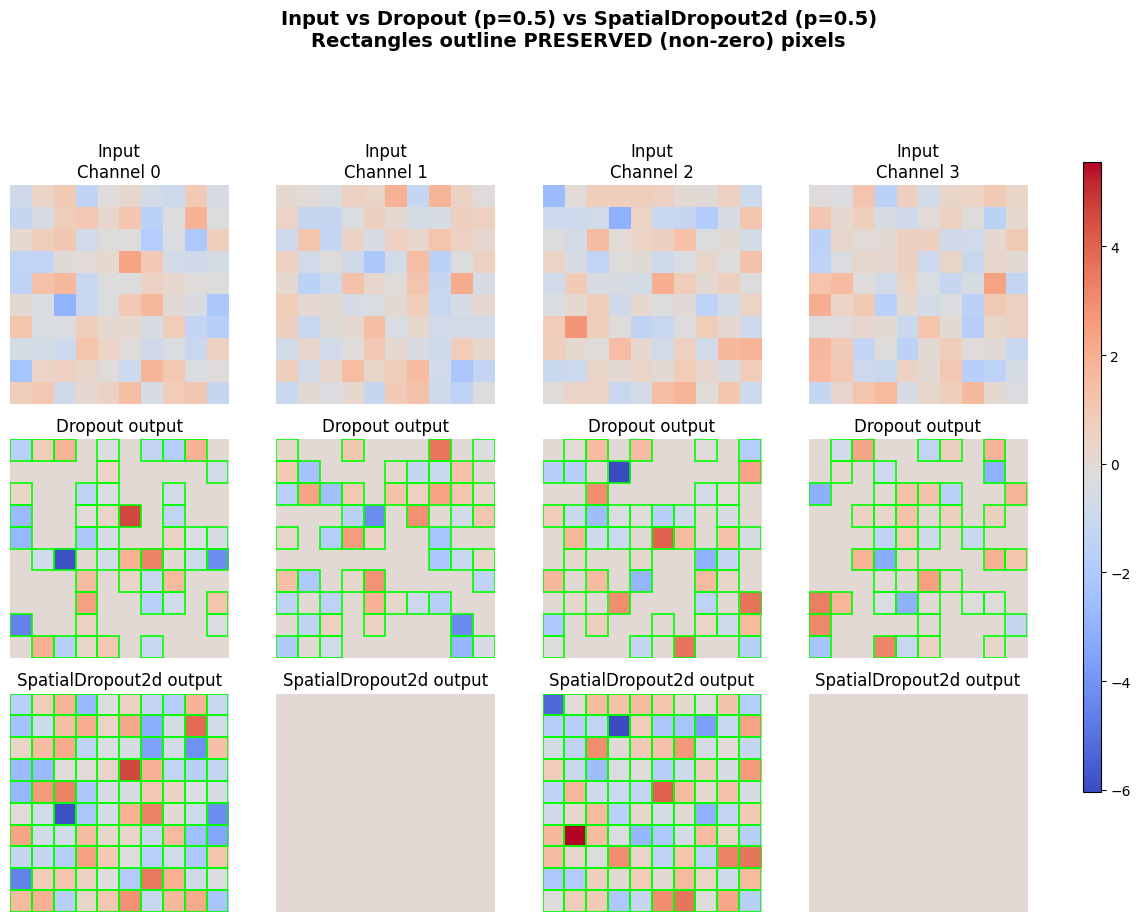

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

torch.manual_seed(7)

N, C, H, W = 1, 4, 10, 10
x = torch.randn(N, C, H, W)

p = 0.5
drop = nn.Dropout(p=p)
drop2d = nn.Dropout2d(p=p)
drop.train(); drop2d.train()

y_drop = drop(x.clone())
y_spat = drop2d(x.clone())

def draw_preserved_rectangles(ax, tensor_channel, color="lime", lw=1.2):
    """
    tensor_channel: 2D tensor [H, W] after dropout
    Draws rectangles around non-zero locations.
    """
    mask = (tensor_channel != 0).cpu()
    for i in range(mask.shape[0]):
        for j in range(mask.shape[1]):
            if mask[i, j]:
                rect = Rectangle((j-0.5, i-0.5), 1.0, 1.0, fill=False, edgecolor=color, linewidth=lw)
                ax.add_patch(rect)

vmin = min(x.min().item(), y_drop.min().item(), y_spat.min().item())
vmax = max(x.max().item(), y_drop.max().item(), y_spat.max().item())

rows = 3
fig, axes = plt.subplots(rows, C, figsize=(3*C, 3*rows))
fig.suptitle(f"Input vs Dropout (p={p}) vs SpatialDropout2d (p={p})\nRectangles outline PRESERVED (non-zero) pixels", fontsize=14, weight="bold", y=1.02)

for c in range(C):
    ax0 = axes[0, c] if C > 1 else axes[0]
    im0 = ax0.imshow(x[0, c].detach().cpu(), cmap="coolwarm", interpolation="nearest", vmin=vmin, vmax=vmax)
    ax0.set_title(f"Input\nChannel {c}")
    ax0.axis("off")

    ax1 = axes[1, c] if C > 1 else axes[1]
    im1 = ax1.imshow(y_drop[0, c].detach().cpu(), cmap="coolwarm", interpolation="nearest", vmin=vmin, vmax=vmax)
    draw_preserved_rectangles(ax1, y_drop[0, c])
    ax1.set_title("Dropout output")
    ax1.axis("off")

    ax2 = axes[2, c] if C > 1 else axes[2]
    im2 = ax2.imshow(y_spat[0, c].detach().cpu(), cmap="coolwarm", interpolation="nearest", vmin=vmin, vmax=vmax)
    draw_preserved_rectangles(ax2, y_spat[0, c])
    ax2.set_title("SpatialDropout2d output")
    ax2.axis("off")

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im0, cax=cbar_ax)

plt.tight_layout(rect=[0,0,0.9,0.95])
plt.show()


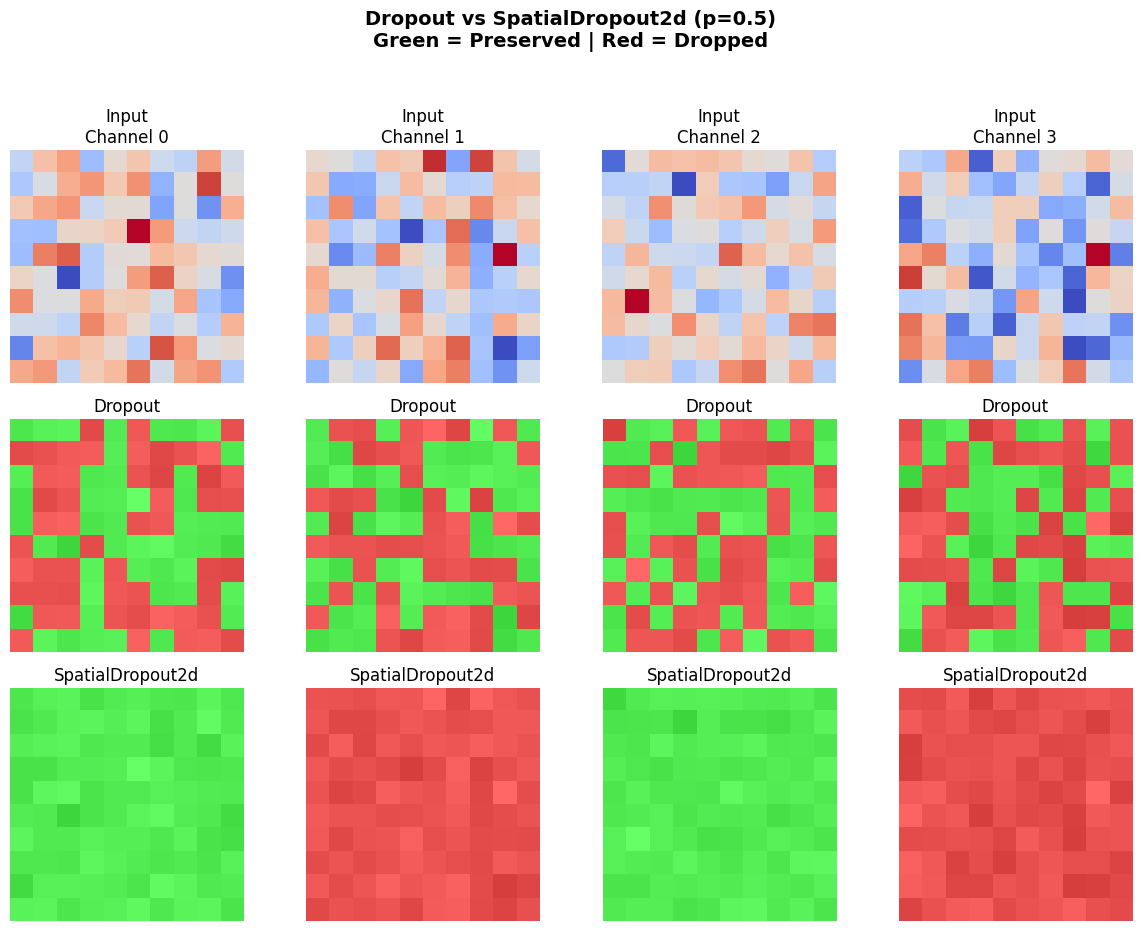

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(7)

N, C, H, W = 1, 4, 10, 10
x = torch.randn(N, C, H, W)

p = 0.5
drop = nn.Dropout(p=p)
drop2d = nn.Dropout2d(p=p)
drop.train()
drop2d.train()

y_drop = drop(x.clone())
y_spat = drop2d(x.clone())

mask_drop = (y_drop != 0).float()[0]
mask_spat = (y_spat != 0).float()[0]

def create_overlay(mask):
    overlay = np.zeros((H, W, 3))
    overlay[mask == 1] = [0, 1, 0]  # green for kept
    overlay[mask == 0] = [1, 0, 0]  # red for dropped
    return overlay

rows = 3
fig, axes = plt.subplots(rows, C, figsize=(3*C, 3*rows))
fig.suptitle(f"Dropout vs SpatialDropout2d (p={p})\nGreen = Preserved | Red = Dropped", fontsize=14, weight="bold", y=1.03)

for c in range(C):
    ax0 = axes[0, c]
    ax0.imshow(x[0, c].detach(), cmap="coolwarm", interpolation="nearest")
    ax0.set_title(f"Input\nChannel {c}")
    ax0.axis("off")

    ax1 = axes[1, c]
    ax1.imshow(x[0, c].detach(), cmap="gray", alpha=0.4)
    ax1.imshow(create_overlay(mask_drop[c]), alpha=0.6)
    ax1.set_title("Dropout")
    ax1.axis("off")

    ax2 = axes[2, c]
    ax2.imshow(x[0, c].detach(), cmap="gray", alpha=0.4)
    ax2.imshow(create_overlay(mask_spat[c]), alpha=0.6)
    ax2.set_title("SpatialDropout2d")
    ax2.axis("off")

plt.tight_layout()
plt.show()


## **Argument: Interpreting Dropout as a Variety of Architectural Regularization**



### 1. Structural Justification

From a structural perspective, **Dropout** can be interpreted as a *dynamic architectural regularization mechanism*.
During training, Dropout randomly deactivates a fraction ($p$) of the neurons in a given layer, effectively **reconfiguring the network topology** at every training iteration. Each stochastic configuration constitutes a *thinned sub-architecture* of the full network, where specific connections between neurons are temporarily removed. Mathematically, this can be expressed as:

$$
h' = h \odot r, \quad r_i \sim \text{Bernoulli}(1-p)
$$

where $h$ represents neuron activations and $r$ is a binary mask controlling which connections remain active.
This stochastic masking can be viewed as **sampling from a family of sub-networks**, each with distinct connectivity, but sharing the same parameter set $W$.
Consequently, Dropout can be regarded as an **architectural regularizer**, since it influences the *connectivity structure* of the network itself rather than merely adjusting the magnitude of its parameters.

This view is supported by the "thinned networks" interpretation of Dropout, in Srivastava et al. 2014. Under this view, Dropout behaves as a **stochastic architectural sampling mechanism**, implicitly regularizing the model by constraining its expected connectivity pattern.

---

### 2. Comparison with DropConnect

**DropConnect** extends this architectural notion further by randomly dropping individual **weights** instead of **neuron outputs**. In DropConnect, the random mask (M) is applied directly to the weight matrix:

$$
z = (W \odot M)x, \quad M_{ij} \sim \text{Bernoulli}(1-p)
$$

This approach leads to **stochastic connectivity at the weight level**, producing a structurally different network at each iteration, similar in principle to Dropout but with finer granularity.
DropConnect thus represents a **stronger architectural perturbation**, since it modifies the actual edge connectivity pattern between input and output units, whereas Dropout modifies node (neuron) activation patterns.

Under this lens, both methods may be described as forms of *architectural regularization*. They introduce stochasticity into the network's topology, thereby discouraging dependence on specific pathways or neurons.

---

### 3. Classification Alignment with Mainstream Literature

Despite this structural interpretation, the mainstream view in deep learning research and pedagogy categorizes **Dropout primarily as a data-based or stochastic regularization technique**, rather than as an architectural one.
This is because:

1. The network’s **underlying architecture remains unchanged**. The Dropout mask only perturbs activations *temporarily* during training.
2. The regularization effect arises not from a permanent architectural constraint, but from **randomized perturbations of feature representations**, functionally similar to **noise injection** or **data augmentation** in feature space.
3. At inference time, Dropout is disabled, and the **original architecture is restored** (with weights scaled by $1-p$), distinguishing it from true architectural modifications such as weight sharing or normalization layers that persist at test time.

Hence, although Dropout can **structurally be interpreted as an architectural regularizer**, its operational mechanism and transient stochastic nature align it more closely with **data-based or noise-based regularization techniques**.

---


---